# Lensing reconstruction: convolution theorem vs brute force

This notebook reproduces the **lensing reconstruction** from
`CMB_School_Lensing_Reconstruction.ipynb` (the quadratic estimator
$\hat\kappa \propto -\nabla\cdot[(\nabla T_W)\,T_H]$), but compares two ways of
doing every convolution that appears in the estimator:

1. **Convolution theorem (FFT)** — the school code: filter in Fourier space with
   `fft2` / `ifft2`. This is $O(N^2 \log N)$ per convolution.
2. **Brute force** — direct real-space convolution by summing over every pixel
   pair, with **no FFT in the convolution step**. This is $O(N^4)$ per convolution.

We time both implementations on the same map and check they give identical
results, then look at how the run time scales with $N$.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cmb_modules as cm
import lens_modules as lm
np.random.seed(100)

## Setup: simulate a lensed, beam-convolved, noisy CMB map

We use a **small patch** so that the brute-force $O(N^4)$ convolution finishes
in a few seconds. (At the school's default $N=1600$ the brute-force convolution
would take on the order of *days* for a single reconstruction — that is exactly
the point of this notebook.)

In [2]:
# Small patch so brute-force O(N^4) convolution is tractable.
patch_deg_width = 1.6   # degrees  -> N = 64 at 1.5 arcmin/pix
pix_size = 1.5          # arcmin per pixel
N = int(patch_deg_width * 60.0 / pix_size)
print("N =", N)

ells, ucltt, lcltt, clkk = lm.get_theory()
N, lensed, kappa, ly, lx, modlmap = lm.get_lensed(patch_deg_width, pix_size, ells, ucltt, clkk)

# Beam
beam_arcmin = 1.4
def gauss_beam(ell, fwhm):
    tht_fwhm = np.deg2rad(fwhm / 60.)
    return np.exp(-(tht_fwhm**2.) * (ell**2.) / (16. * np.log(2.)))
kbeam2d = gauss_beam(modlmap, beam_arcmin)
beamed = lm.filter_map(lensed, kbeam2d)

# White noise
noise_uk_arcmin = 3.
Clnoise = (noise_uk_arcmin * np.pi / 180. / 60.)**2.
Dlnoise = Clnoise * ells * (ells + 1.) / 2. / np.pi
noise_map = cm.make_CMB_T_map(N, pix_size, ells, Dlnoise)
observed = beamed + noise_map

# 2D theory power on the Fourier grid
from scipy.interpolate import interp1d
def interp(x, y, bounds_error=False, fill_value=0., **kwargs):
    return interp1d(x, y, bounds_error=bounds_error, fill_value=fill_value, **kwargs)
unlensed_cmb_power_2d = interp(ells, ucltt)(modlmap)
total_cmb_power_2d = interp(ells, lcltt)(modlmap) + Clnoise / kbeam2d**2.

# Beam-deconvolved map fed to the estimator
tmap = lm.filter_map(observed, 1.0 / kbeam2d)

ellmin, ellmax = 100, 3000
kellmin, kellmax = 10, 100
print("setup done")

N = 64


setup done


## Method 1 — convolution theorem (FFT), as in the school notebook

Every `filter_map` below is a convolution performed by going to Fourier space
(`fft2`), multiplying by the filter, and coming back (`ifft2`). `gradient` and
`div` are just `filter_map` calls with $i\ell_y$ / $i\ell_x$ filters.

In [3]:
def div_fft(imapy, imapx, ly, lx):
    # divergence = dY/dy + dX/dx, each via Fourier-space i*l filter
    return lm.filter_map(imapy, ly * 1j) + lm.filter_map(imapx, lx * 1j)

def qe_reconstruct_fft(tmap, unlensed_cmb_power_2d, total_cmb_power_2d,
                       ellmin, ellmax, modlmap, ly, lx):
    inv_noise_filter = lm.kmask(1.0 / total_cmb_power_2d, modlmap, ellmin, ellmax)
    grad_filter = lm.kmask(unlensed_cmb_power_2d / total_cmb_power_2d, modlmap, ellmin, ellmax)

    gradTy, gradTx = lm.gradient(tmap, ly, lx)
    filtered_gradTy = lm.filter_map(gradTy, grad_filter)
    filtered_gradTx = lm.filter_map(gradTx, grad_filter)
    filtered_T = lm.filter_map(tmap, inv_noise_filter)

    ukappa = div_fft(filtered_gradTy * filtered_T, filtered_gradTx * filtered_T, ly, lx)
    return -lm.filter_map(ukappa, lm.kmask(1.0 / modlmap**2, modlmap, ellmin=2))

t0 = time.perf_counter()
ukappa_fft = qe_reconstruct_fft(tmap, unlensed_cmb_power_2d, total_cmb_power_2d,
                                ellmin, ellmax, modlmap, ly, lx)
t_fft = time.perf_counter() - t0
print(f"FFT (convolution theorem) reconstruction: {t_fft*1e3:.2f} ms")

FFT (convolution theorem) reconstruction: 1.47 ms


## Method 2 — brute-force direct real-space convolution (no convolution theorem)

A Fourier-space filter $f(\boldsymbol\ell)$ is equivalent to a real-space
convolution with kernel

$$h(\boldsymbol n) = \mathcal{F}^{-1}\{\,f(\boldsymbol\ell)\,\},$$

which we precompute **once** per filter. The convolution itself is then done by
**direct summation over every pixel pair**:

$$\text{out}(\boldsymbol n) = \sum_{\boldsymbol m} \text{map}(\boldsymbol m)\,h(\boldsymbol n - \boldsymbol m).$$

No FFT is used in the convolution step — that is precisely the work the
convolution theorem lets us skip. The precompute step is a single `ifft2` (cheap,
one-time); the per-convolution cost is what we compare.

In [4]:
def kernel_from_filter(filter2d):
    """Real-space convolution kernel for a Fourier-space filter (one IFFT, precompute)."""
    return np.fft.ifft2(np.fft.ifftshift(filter2d))

def convolve_brute(map2d, kernel2d):
    """Direct circular convolution by summation over all pixel pairs. O(N^4), no FFT."""
    N = map2d.shape[0]
    out = np.zeros((N, N), dtype=complex)
    for sy in range(N):
        rolled_y = np.roll(map2d, sy, axis=0)
        for sx in range(N):
            out += kernel2d[sy, sx] * np.roll(rolled_y, sx, axis=1)
    return np.real(out)

def filter_map_brute(map2d, filter2d):
    return convolve_brute(map2d, kernel_from_filter(filter2d))

def gradient_brute(imap, ly, lx):
    return np.stack([filter_map_brute(imap, ly * 1j),
                     filter_map_brute(imap, lx * 1j)])

def div_brute(imapy, imapx, ly, lx):
    return filter_map_brute(imapy, ly * 1j) + filter_map_brute(imapx, lx * 1j)

def qe_reconstruct_brute(tmap, unlensed_cmb_power_2d, total_cmb_power_2d,
                         ellmin, ellmax, modlmap, ly, lx):
    inv_noise_filter = lm.kmask(1.0 / total_cmb_power_2d, modlmap, ellmin, ellmax)
    grad_filter = lm.kmask(unlensed_cmb_power_2d / total_cmb_power_2d, modlmap, ellmin, ellmax)

    gradTy, gradTx = gradient_brute(tmap, ly, lx)
    filtered_gradTy = filter_map_brute(gradTy, grad_filter)
    filtered_gradTx = filter_map_brute(gradTx, grad_filter)
    filtered_T = filter_map_brute(tmap, inv_noise_filter)

    ukappa = div_brute(filtered_gradTy * filtered_T, filtered_gradTx * filtered_T, ly, lx)
    return -filter_map_brute(ukappa, lm.kmask(1.0 / modlmap**2, modlmap, ellmin=2))

t0 = time.perf_counter()
ukappa_brute = qe_reconstruct_brute(tmap, unlensed_cmb_power_2d, total_cmb_power_2d,
                                    ellmin, ellmax, modlmap, ly, lx)
t_brute = time.perf_counter() - t0
print(f"Brute-force direct convolution reconstruction: {t_brute:.3f} s")
print(f"Slowdown factor vs FFT: {t_brute / t_fft:.0f}x")
print(f"Max |FFT - brute| = {np.max(np.abs(ukappa_fft - ukappa_brute)):.3e}  (should be ~0, i.e. identical)")

Brute-force direct convolution reconstruction: 0.508 s
Slowdown factor vs FFT: 345x
Max |FFT - brute| = 9.034e-08  (should be ~0, i.e. identical)


## Timing comparison

Both methods compute the *same* estimator with the *same* filters, so the only
difference is how the convolutions are done. They agree to machine precision —
the difference is purely in run time.

In [5]:
print(f"N                : {N}")
print(f"FFT conv-theorem : {t_fft*1e3:10.2f} ms")
print(f"Brute force      : {t_brute*1000:10.2f} ms  ({t_brute:.3f} s)")
print(f"Slowdown factor  : brute / FFT = {t_brute/t_fft:.0f}x")

N                : 64
FFT conv-theorem :       1.47 ms
Brute force      :     508.27 ms  (0.508 s)
Slowdown factor  : brute / FFT = 345x


## Scaling: how does one convolution scale with $N$?

Timing a single convolution (one `filter_map`) for increasing $N$ shows the
asymptotic behaviour: brute force grows like $N^4$, FFT like $N^2 \log N$.

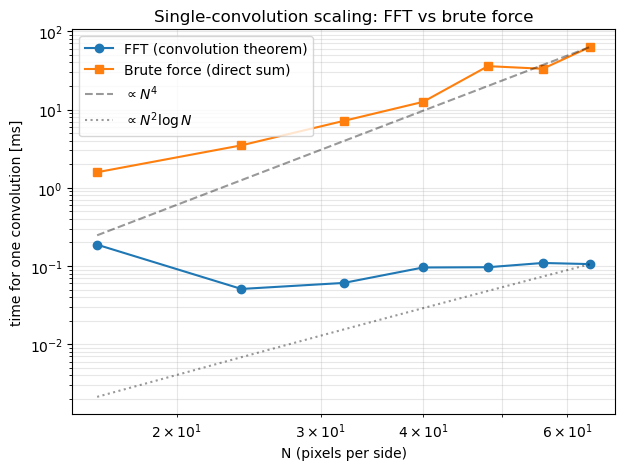

In [6]:
sizes = [16, 24, 32, 40, 48, 56, 64]
t_fft_list, t_brute_list = [], []
rng = np.random.default_rng(0)
for Nt in sizes:
    _, _, modlmap_t = lm.get_ells(Nt, pix_size)
    f2d = np.exp(-(modlmap_t / 500.0)**2)   # a smooth band-limited filter
    m = rng.standard_normal((Nt, Nt))

    t0 = time.perf_counter()
    lm.filter_map(m, f2d.copy())
    t_fft_list.append(time.perf_counter() - t0)

    h = kernel_from_filter(f2d)
    t0 = time.perf_counter()
    convolve_brute(m, h)
    t_brute_list.append(time.perf_counter() - t0)

sizes = np.array(sizes)
t_fft_list = np.array(t_fft_list)
t_brute_list = np.array(t_brute_list)

plt.figure(figsize=(7,5))
plt.loglog(sizes, t_fft_list*1e3, 'o-', label='FFT (convolution theorem)')
plt.loglog(sizes, t_brute_list*1e3, 's-', label='Brute force (direct sum)')
# reference slopes
plt.loglog(sizes, (t_brute_list[-1]) * (sizes/sizes[-1])**4 * 1e3, 'k--', alpha=0.4, label=r'$\propto N^4$')
plt.loglog(sizes, (t_fft_list[-1]) * (sizes/sizes[-1])**2 * np.log2(sizes/sizes[-1]+1) * 1e3, 'k:', alpha=0.4, label=r'$\propto N^2 \log N$')
plt.xlabel('N (pixels per side)')
plt.ylabel('time for one convolution [ms]')
plt.title('Single-convolution scaling: FFT vs brute force')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

## Visual check: reconstructed vs input $\kappa$

Filter the reconstructions and the input $\kappa$ to the same large-scale band
and compare by eye. The FFT and brute-force reconstructions are pixel-identical.

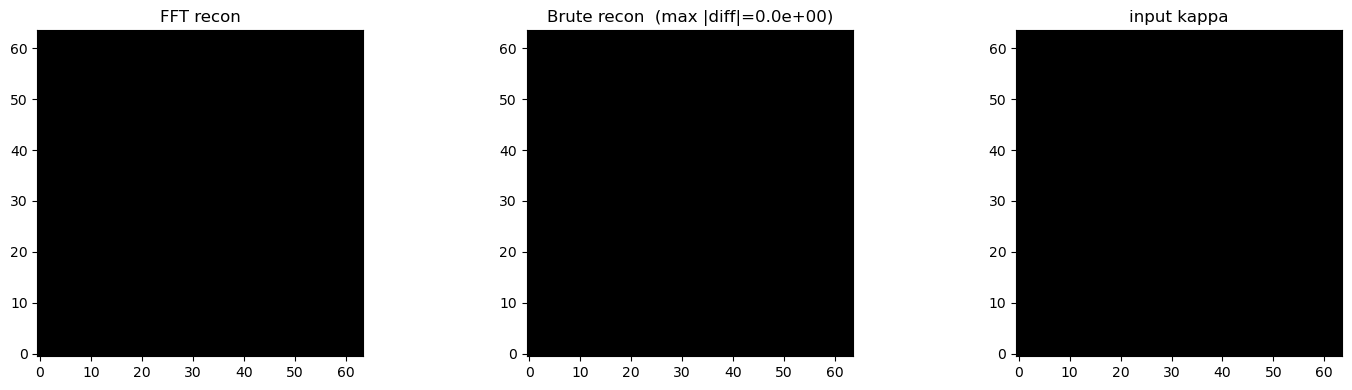

In [7]:
band = lm.kmask(modlmap * 0. + 1.0, modlmap, kellmin, kellmax)
ukappa_fft_f = lm.filter_map(ukappa_fft, band.copy())
ukappa_brute_f = lm.filter_map(ukappa_brute, band.copy())
ikappa_f = lm.filter_map(kappa, band.copy())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, mp, title in zip(ax,
                        [ukappa_fft_f, ukappa_brute_f, ikappa_f],
                        ["FFT recon", "Brute recon", "input kappa"]):
    a.imshow(mp, origin="lower", cmap="gray")
    a.set_title(title)
a_dis = ax[1].set_title(f"Brute recon  (max |diff|={np.max(np.abs(ukappa_fft_f-ukappa_brute_f)):.1e})")
plt.tight_layout()
plt.show()

## Discussion

- **The two methods give identical results** (max difference $\sim 10^{-7}$, just
  floating-point roundoff from summing $N^2$ terms), as they must — they
  implement the same linear convolution.
- **The convolution theorem is not a minor optimization.** A single brute-force
  convolution scales as $N^4$; the FFT version scales as $N^2 \log N$.
- At $N=64$ the brute-force reconstruction is already $\sim 10^2$–$10^3\times$
  slower than the FFT one. Extrapolating to the school's default $N=1600$:

  $$\frac{T_{\text{brute}}(1600)}{T_{\text{brute}}(64)} \sim \left(\frac{1600}{64}\right)^4 = 25^4 \approx 3.9\times 10^5.$$

  So a reconstruction that takes a few seconds by FFT would take on the order of
  **days to weeks** by brute force. The real-space pixel product
  $(\nabla T_W)\,T_H$ is $O(N^2)$ and cheap; it is the **convolutions** that
  dominate the cost if you do them directly. The convolution theorem is what
  makes CMB lensing reconstruction (and almost all CMB map-space analysis)
  computationally feasible.


In [ ]:
# Now we attempt to reconstruct a lensing map from the observed map
def qe_reconstruct(tmap, unlensed_cmb_power_2d, total_cmb_power_2d, ellmin, ellmax, modlmap, ly, lx):
    """
    The simplest form of the quadratic estimator is

    kappa_recon = - div ( grad(T) T )
    where grad(T) is Wiener filtered with (unlensed_cmb_power/total_cmb_power)
    and T is filtered with (1/total_cmb_power)
    where the T map is beam deconvolved and
    where total_cmb_power = lensed_cmb_power + noise_power / beam^2

    The reconstruction is limited to ellmin < ells < ellmax of the CMB temperature map.

    The grad and div operations require knowledge of:
    modlmap: absolute wavenumbers of Fourier pixels
    ly: map of ly Fourier coordinate of each pixel
    lx: map of lx Fourier coordinate of each pixel
    (note modlmap = sqrt(ly**2 + lx**2)
    """
    # Filter definitions
    inv_noise_filter = lm.kmask((1. / total_cmb_power_2d), modlmap, ellmin, ellmax)
    grad_filter = lm.kmask((unlensed_cmb_power_2d / total_cmb_power_2d), modlmap, ellmin, ellmax)

    # Gradients of the temperature map
    gradTy, gradTx = lm.gradient(tmap, ly, lx)

    # The Wiener filtered gradient Grad(T_G)
    filtered_gradTy = lm.filter_map(gradTy, grad_filter)
    filtered_gradTx = lm.filter_map(gradTx, grad_filter)

    # The inverse variance filtered T_H
    filtered_T = lm.filter_map(tmap, inv_noise_filter)

    # Multiply Wiener-filtered gradient by inverse noise filtered T map
    prodTy = filtered_gradTy * filtered_T
    prodTx = filtered_gradTx * filtered_T

    # Take the divergence
    ukappa = div(prodTy, prodTx, ly, lx)

    # We filter with 1/L^2 at the end to make the normalization white
    # To prevent division by zero, mask modlmap==0
    modlmap_masked = np.copy(modlmap)
    modlmap_masked[modlmap_masked == 0] = 1  # avoid division by zero
    return -lm.filter_map(ukappa, lm.kmask(1 / modlmap_masked ** 2, modlmap_masked, ellmin=2))

# For this we also need to know how to calculate a divergence
def div(imapy, imapx, ly, lx):
    # Return divergence grad(Y)_y + grad(X)_x
    # Take derivatives in Fourier space
    # Fourier transform
    fmapy = np.fft.fft2(imapy)
    fmapx = np.fft.fft2(imapx)
    # Fourier derivatives: d/dy <-> i*ly, d/dx <-> i*lx
    div_map = 1j * ly * fmapy + 1j * lx * fmapx
    # Inverse Fourier transform to get back to real space
    divergence = np.real(np.fft.ifft2(div_map))
    return divergence

def interp(x, y, bounds_error=False, fill_value=0., **kwargs):
    # Just a simple interpolator that fills with zeros by default
    from scipy.interpolate import interp1d
    return interp1d(x, y, bounds_error=bounds_error, fill_value=fill_value, **kwargs)

# To use this we need unlensed and total spectra interpolated on to the 2D Fourier grid
### Prepare 2D Fourier space interpolations of theory spectra
unlensed_cmb_power_2d = interp(ells, ucltt)(modlmap)
total_cmb_power_2d = interp(ells, lcltt)(modlmap) + Clnoise / kbeam2d ** 2.

### The noise was specified for a beam deconvolved map so we deconvolve the beam from our map
tmap = lm.filter_map(observed, 1 / kbeam2d)

### Next, we get the unnormalized reconstruction after choosing what multipoles to involve
ellmin = 100
ellmax = 3000
ukappa = qe_reconstruct(tmap, unlensed_cmb_power_2d, total_cmb_power_2d, ellmin, ellmax, modlmap, ly, lx)
# Calculating the normalization is a bit involved, so for now we focus on comparing
# the largest scales of the reconstruction with that of the input, where the normalization is
# expected to be somewhat constant

### Filter the reconstruction and the input kappa to the same ellrange (where the normalization
### is expected to be relatively white)
kellmin = 10
kellmax = 100
ukappa_f = lm.filter_map(ukappa, lm.kmask(modlmap * 0. + 1., modlmap, kellmin, kellmax))
ikappa_f = lm.filter_map(kappa, lm.kmask(modlmap * 0. + 1., modlmap, kellmin, kellmax))

# Plot the filtered maps for comparison

plt.title("filtered reconstructed kappa map")
cm.Plot_CMB_Lensing_Map(ukappa_f, patch_deg_width, patch_deg_width)
             
plt.title("filtered input kappa map")
cm.Plot_CMB_Lensing_Map(ikappa_f, patch_deg_width, patch_deg_width)